In [ ]:
# Visualize CTC Training Images

# Notebook เพื่อ debug และดูภาพที่ train_ctc.py ใช้ในการเทรน  
# ใช้วิธีการดึงภาพเหมือนกับ train_ctc.py ทุกประการ (ผ่าน `load_plate_crop` จาก data_utils.py)

In [5]:
# Setup: Import และ Path configuration (เหมือน train_ctc.py)
import sys
from pathlib import Path
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import matplotlib.font_manager as fm

# Setup project root (เหมือน train_ctc.py)
PROJECT_ROOT = Path(r'C:\Users\Tanaphat\Desktop\Coding\ALPR')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import จาก train modules (เหมือนที่ train_ctc.py ใช้)
from train.data_utils import LicensePlateRecord, load_plate_crop, load_records, stratified_split

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ตั้งค่า font สำหรับภาษาไทย
def setup_thai_font():
    """ตั้งค่า matplotlib ให้รองรับภาษาไทย"""
    # Font ที่รองรับภาษาไทยบน Windows (ตามลำดับความนิยม)
    thai_fonts = ['Tahoma', 'Cordia New', 'Angsana New', 'Browallia New', 'TH SarabunPSK']
    
    # หา font ที่มีในระบบ
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    selected_font = None
    for font in thai_fonts:
        if font in available_fonts:
            selected_font = font
            break
    
    if selected_font:
        plt.rcParams['font.family'] = selected_font
        plt.rcParams['font.sans-serif'] = [selected_font] + plt.rcParams['font.sans-serif']
        print(f"✅ ใช้ font: {selected_font}")
    else:
        # ถ้าไม่เจอ font ไทย ให้ใช้ DejaVu Sans (มี fallback ที่ดี)
        plt.rcParams['font.family'] = 'DejaVu Sans'
        print(f"⚠️  ไม่พบ font ไทย, ใช้ DejaVu Sans (อาจแสดงผลภาษาไทยไม่ถูกต้อง)")
    
    # ตั้งค่าเพิ่มเติมสำหรับ negative sign
    plt.rcParams['axes.unicode_minus'] = False
    
    return selected_font

thai_font = setup_thai_font()

print(f"✅ Imports complete")
print(f"📁 Project root: {PROJECT_ROOT}")

✅ ใช้ font: Tahoma
✅ Imports complete
📁 Project root: C:\Users\Tanaphat\Desktop\Coding\ALPR


In [6]:
# Load records (เหมือน train_ctc.py ทุกประการ)
CSV_PATH = PROJECT_ROOT / 'data' / '8000' / '8000.csv'
DATA_ROOTS = [str(PROJECT_ROOT / 'data' / '8000')]

print(f"📄 Loading CSV: {CSV_PATH}")
print(f"📂 Data roots: {DATA_ROOTS}")

records = load_records(
    str(CSV_PATH),
    data_roots=DATA_ROOTS,
    require_validate=True,
    drop_missing_images=True,
)

print(f"✅ Loaded {len(records)} records")

# ตัวอย่างข้อมูล record
if records:
    sample = records[0]
    print(f"\n📋 Sample record:")
    print(f"   Plate text: {sample.plate_text}")
    print(f"   Province: {sample.province_description}")
    print(f"   Image path: {sample.plate_image_path}")

📄 Loading CSV: C:\Users\Tanaphat\Desktop\Coding\ALPR\data\8000\8000.csv
📂 Data roots: ['C:\\Users\\Tanaphat\\Desktop\\Coding\\ALPR\\data\\8000']
✅ Loaded 8172 records

📋 Sample record:
   Plate text: กง8989
   Province: ราชบุรี
   Image path: C:\Users\Tanaphat\Desktop\Coding\ALPR\data\8000\210\2024-07-05\14\Lane1\2024-07-05_14-00-23-928_TRG-077492_Lane1_กง8989-THA_83.jpg


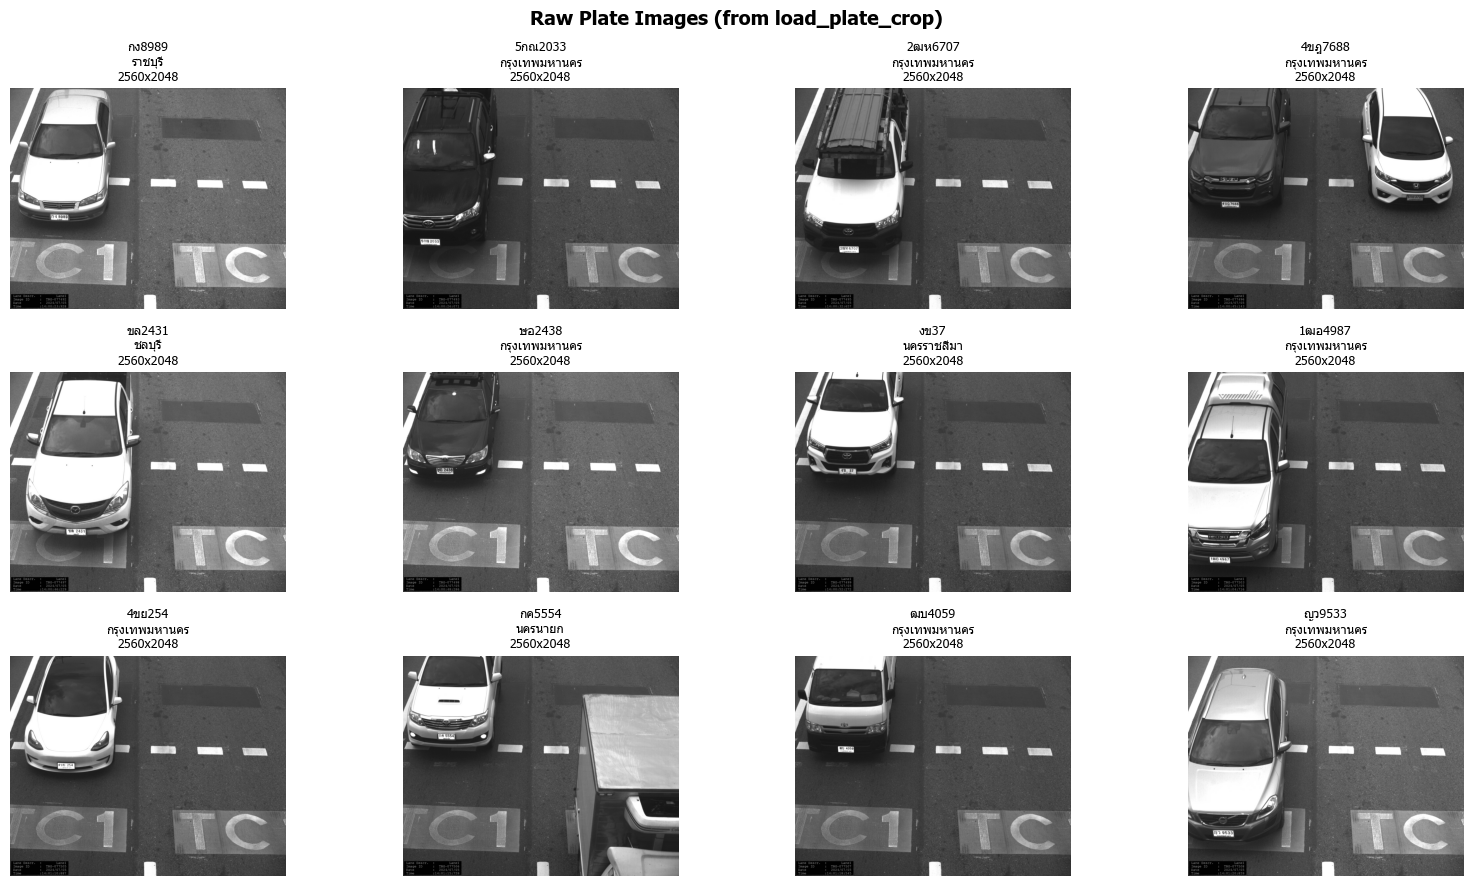

In [7]:
# ดึงภาพด้วย load_plate_crop (เหมือน CTCPlateDataset.__getitem__)
def visualize_raw_images(records, num_samples=12, cols=4):
    """แสดงภาพที่ดึงจาก load_plate_crop ตรง ๆ (ก่อน augment, ก่อน resize)"""
    
    num_samples = min(num_samples, len(records))
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    axes = np.array(axes).reshape(rows, cols) if rows > 1 else np.array([axes])
    flat_axes = axes.flatten()
    
    for idx, (ax, record) in enumerate(zip(flat_axes, records[:num_samples])):
        try:
            # ดึงภาพแบบเดียวกับ train_ctc.py (ผ่าน load_plate_crop)
            img = load_plate_crop(record)  # PIL Image RGB
            
            ax.imshow(img)
            ax.set_title(f"{record.plate_text}\n{record.province_description or ''}\n{img.size[0]}x{img.size[1]}", 
                        fontsize=9)
            ax.axis('off')
        except Exception as e:
            ax.text(0.5, 0.5, f"Error:\n{str(e)[:50]}", 
                   ha='center', va='center', fontsize=8, color='red')
            ax.axis('off')
    
    # ซ่อน axes ที่เหลือ
    for ax in flat_axes[num_samples:]:
        ax.axis('off')
    
    plt.suptitle("Raw Plate Images (from load_plate_crop)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# แสดงภาพ raw
visualize_raw_images(records, num_samples=12, cols=4)

In [8]:
# Import CTCPlateDataset และ augmentation (เหมือน train_ctc.py)
import torchvision.transforms as T

# Copy AugmentationConfig และ SimpleAugmentor จาก train_ctc.py
from dataclasses import dataclass

@dataclass
class AugmentationConfig:
    brightness: float = 0.0
    contrast: float = 0.0
    saturation: float = 0.0
    hue: float = 0.0
    rotation_degrees: float = 0.0
    translate: tuple = (0.0, 0.0)
    scale: tuple = (1.0, 1.0)
    shear: float = 0.0
    blur_prob: float = 0.0
    blur_kernel: int = 3
    noise_prob: float = 0.0
    noise_std: float = 0.01
    erase_prob: float = 0.0
    erase_scale: tuple = (0.02, 0.15)
    erase_ratio: tuple = (0.3, 3.3)

class SimpleAugmentor:
    """Pillow/Numpy based augmentations (เหมือน train_ctc.py)"""
    
    def __init__(self, config: AugmentationConfig):
        self.config = config
    
    def __call__(self, image):
        import cv2
        from PIL import ImageEnhance, ImageFilter
        
        # Color jitter
        if self.config.brightness > 0:
            enhancer = ImageEnhance.Brightness(image)
            factor = 1.0 + random.uniform(-self.config.brightness, self.config.brightness)
            image = enhancer.enhance(factor)
        
        if self.config.contrast > 0:
            enhancer = ImageEnhance.Contrast(image)
            factor = 1.0 + random.uniform(-self.config.contrast, self.config.contrast)
            image = enhancer.enhance(factor)
        
        if self.config.saturation > 0:
            enhancer = ImageEnhance.Color(image)
            factor = 1.0 + random.uniform(-self.config.saturation, self.config.saturation)
            image = enhancer.enhance(factor)
        
        # Geometric transforms
        if self.config.rotation_degrees > 0:
            angle = random.uniform(-self.config.rotation_degrees, self.config.rotation_degrees)
            image = image.rotate(angle, fillcolor=(128, 128, 128))
        
        # Blur
        if random.random() < self.config.blur_prob:
            image = image.filter(ImageFilter.GaussianBlur(radius=self.config.blur_kernel/2))
        
        # Noise
        if random.random() < self.config.noise_prob:
            img_array = np.array(image).astype(np.float32)
            noise = np.random.randn(*img_array.shape) * self.config.noise_std * 255
            img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)
            image = Image.fromarray(img_array)
        
        return image

# สร้าง augmentor (light preset เหมือน default ของ train_ctc.py)
def build_augmentor(name: str):
    name = name.lower()
    if name in {"none", "off"}:
        return None
    if name in {"light", "baseline"}:
        return SimpleAugmentor(AugmentationConfig(
            brightness=0.2, contrast=0.2, saturation=0.1,
            rotation_degrees=3, blur_prob=0.1, noise_prob=0.05
        ))
    if name in {"medium", "mod"}:
        return SimpleAugmentor(AugmentationConfig(
            brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05,
            rotation_degrees=5, blur_prob=0.2, noise_prob=0.1
        ))
    if name in {"heavy", "strong"}:
        return SimpleAugmentor(AugmentationConfig(
            brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1,
            rotation_degrees=8, blur_prob=0.3, noise_prob=0.15,
            erase_prob=0.1
        ))
    return None

augment_fn = build_augmentor("light")
print("✅ Augmentor created (light preset)")

✅ Augmentor created (light preset)


🔍 Images WITH augmentation (ที่จะเข้า training):


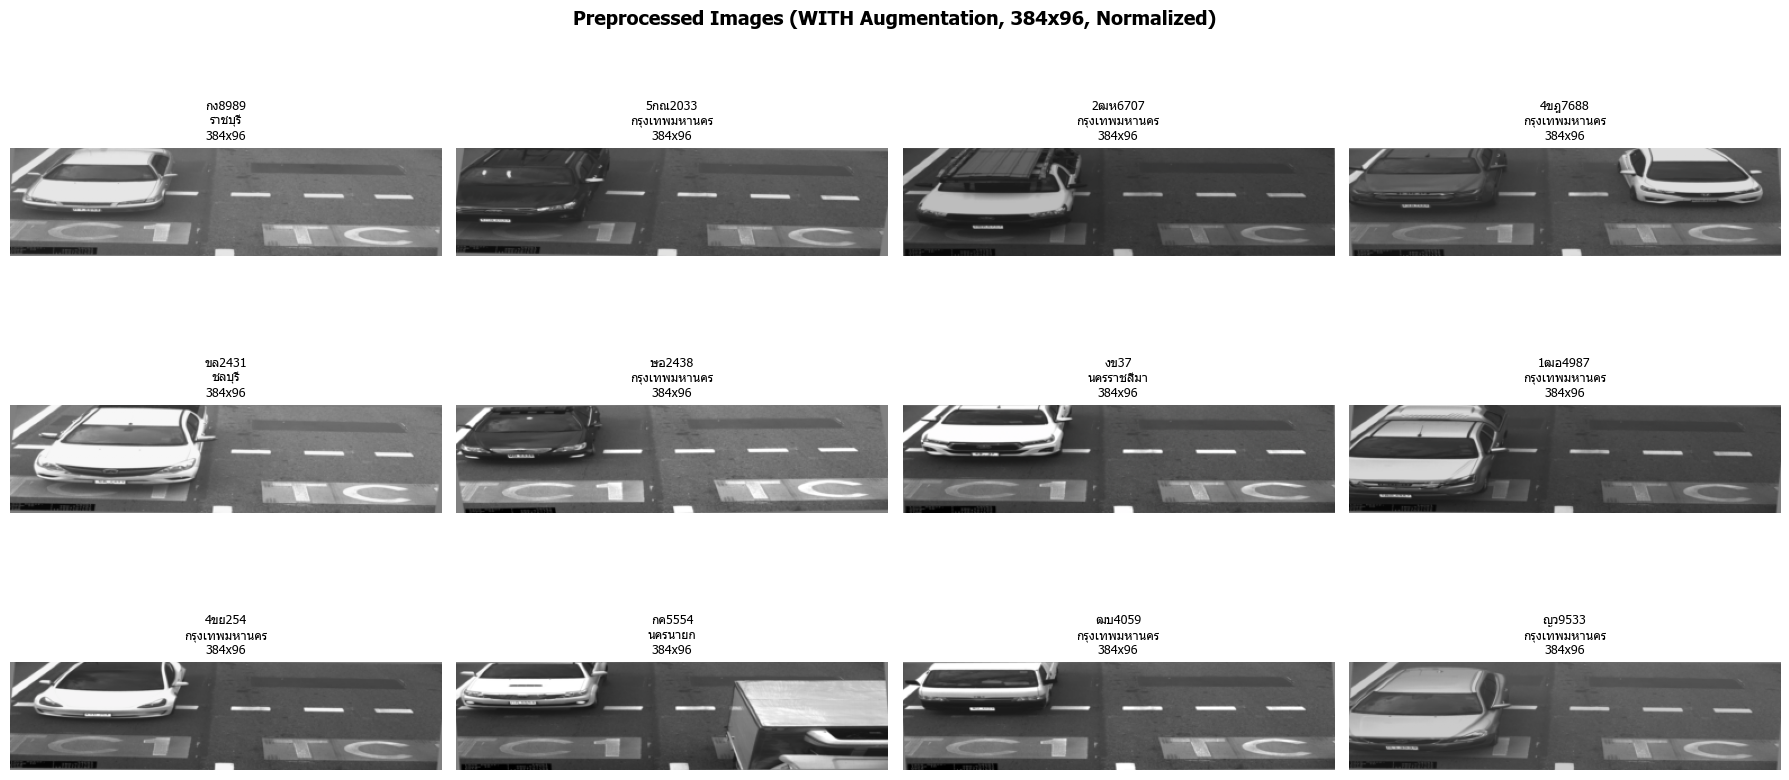

In [9]:
# แสดงภาพ AFTER augmentation + resize (เหมือนที่เข้าโมเดลจริง ๆ)
def visualize_preprocessed_images(records, augment_fn=None, target_height=96, target_width=384, 
                                  num_samples=12, cols=4):
    """แสดงภาพหลังผ่าน augmentation + resize (เหมือนที่เข้า model)"""
    
    num_samples = min(num_samples, len(records))
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*3))
    axes = np.array(axes).reshape(rows, cols) if rows > 1 else np.array([axes])
    flat_axes = axes.flatten()
    
    for idx, (ax, record) in enumerate(zip(flat_axes, records[:num_samples])):
        try:
            # ดึงภาพแบบเดียวกับ CTCPlateDataset.__getitem__
            img = load_plate_crop(record)  # PIL Image
            
            # Apply augmentation (ถ้ามี)
            if augment_fn:
                img = augment_fn(img)
            
            # Resize (เหมือน CTCPlateDataset)
            img = img.resize((target_width, target_height), Image.BILINEAR)
            
            # Convert to tensor (เหมือน CTCPlateDataset)
            img_tensor = T.ToTensor()(img)  # [3, H, W] ใน range [0, 1]
            
            # Normalize (เหมือน CTCPlateDataset)
            normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            img_tensor = normalize(img_tensor)
            
            # Denormalize เพื่อแสดงผล
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img_denorm = img_tensor * std + mean
            img_denorm = torch.clamp(img_denorm, 0, 1)
            
            # Convert to numpy for display
            img_np = img_denorm.permute(1, 2, 0).numpy()
            
            ax.imshow(img_np)
            ax.set_title(f"{record.plate_text}\n{record.province_description or ''}\n{target_width}x{target_height}", 
                        fontsize=9)
            ax.axis('off')
        except Exception as e:
            ax.text(0.5, 0.5, f"Error:\n{str(e)[:50]}", 
                   ha='center', va='center', fontsize=8, color='red')
            ax.axis('off')
    
    # ซ่อน axes ที่เหลือ
    for ax in flat_axes[num_samples:]:
        ax.axis('off')
    
    aug_status = "WITH Augmentation" if augment_fn else "NO Augmentation"
    plt.suptitle(f"Preprocessed Images ({aug_status}, {target_width}x{target_height}, Normalized)", 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# แสดงภาพที่จะเข้าโมเดลจริง ๆ (with augmentation)
print("🔍 Images WITH augmentation (ที่จะเข้า training):")
visualize_preprocessed_images(records, augment_fn=augment_fn, 
                              target_height=96, target_width=384,
                              num_samples=12, cols=4)

🎯 Comparing augmentation for: 3ฒฬ1790


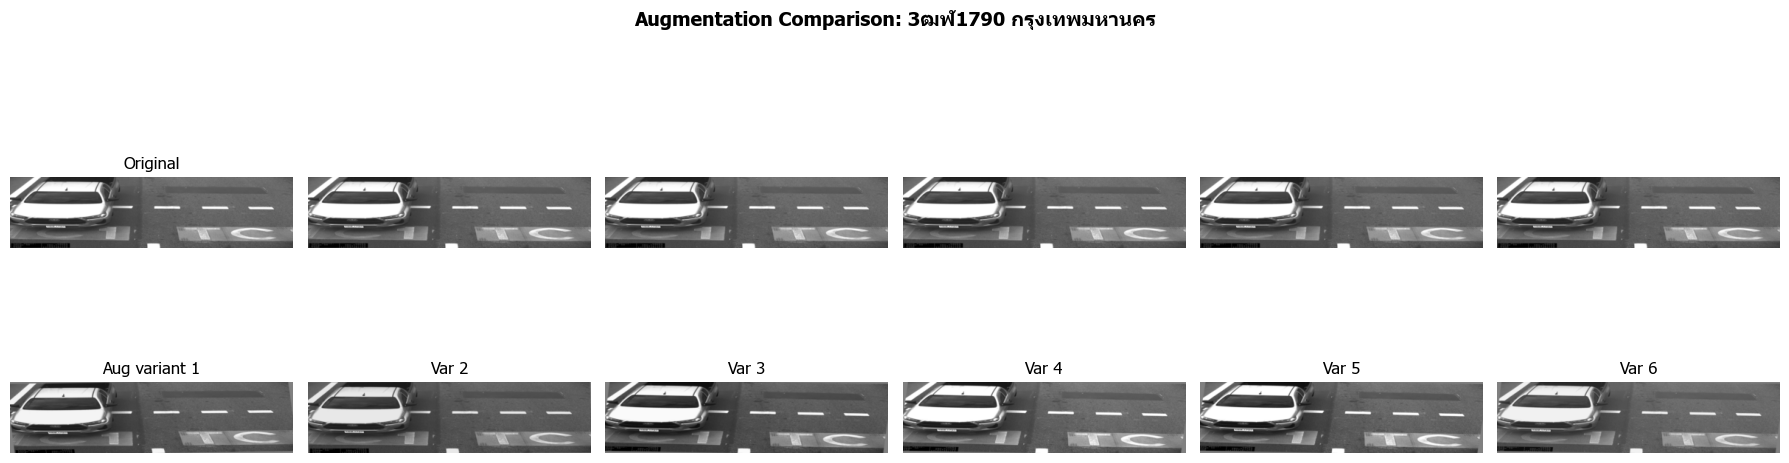

In [10]:
# เปรียบเทียบภาพเดียวกัน: ก่อน vs หลัง augmentation
def compare_augmentation(record, augment_fn, target_height=96, target_width=384, num_variants=6):
    """แสดงภาพเดียวกันหลาย variant เพื่อดู effect ของ augmentation"""
    
    fig, axes = plt.subplots(2, num_variants, figsize=(num_variants*3, 6))
    
    # แถวบน: Original (no aug)
    for i in range(num_variants):
        img = load_plate_crop(record)
        img_resized = img.resize((target_width, target_height), Image.BILINEAR)
        axes[0, i].imshow(img_resized)
        axes[0, i].set_title("Original" if i == 0 else "")
        axes[0, i].axis('off')
    
    # แถวล่าง: With augmentation (different random variants)
    for i in range(num_variants):
        img = load_plate_crop(record)
        if augment_fn:
            img = augment_fn(img)  # แต่ละครั้งจะได้ augmentation ต่างกัน (random)
        img_resized = img.resize((target_width, target_height), Image.BILINEAR)
        axes[1, i].imshow(img_resized)
        axes[1, i].set_title(f"Aug variant {i+1}" if i == 0 else f"Var {i+1}")
        axes[1, i].axis('off')
    
    fig.suptitle(f"Augmentation Comparison: {record.plate_text} {record.province_description or ''}", 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# เลือก record สุ่มมาดู
if records:
    sample_record = random.choice(records[:50])
    print(f"🎯 Comparing augmentation for: {sample_record.plate_text}")
    compare_augmentation(sample_record, augment_fn, num_variants=6)

🔍 Images WITHOUT augmentation (ที่จะเข้า validation/test):


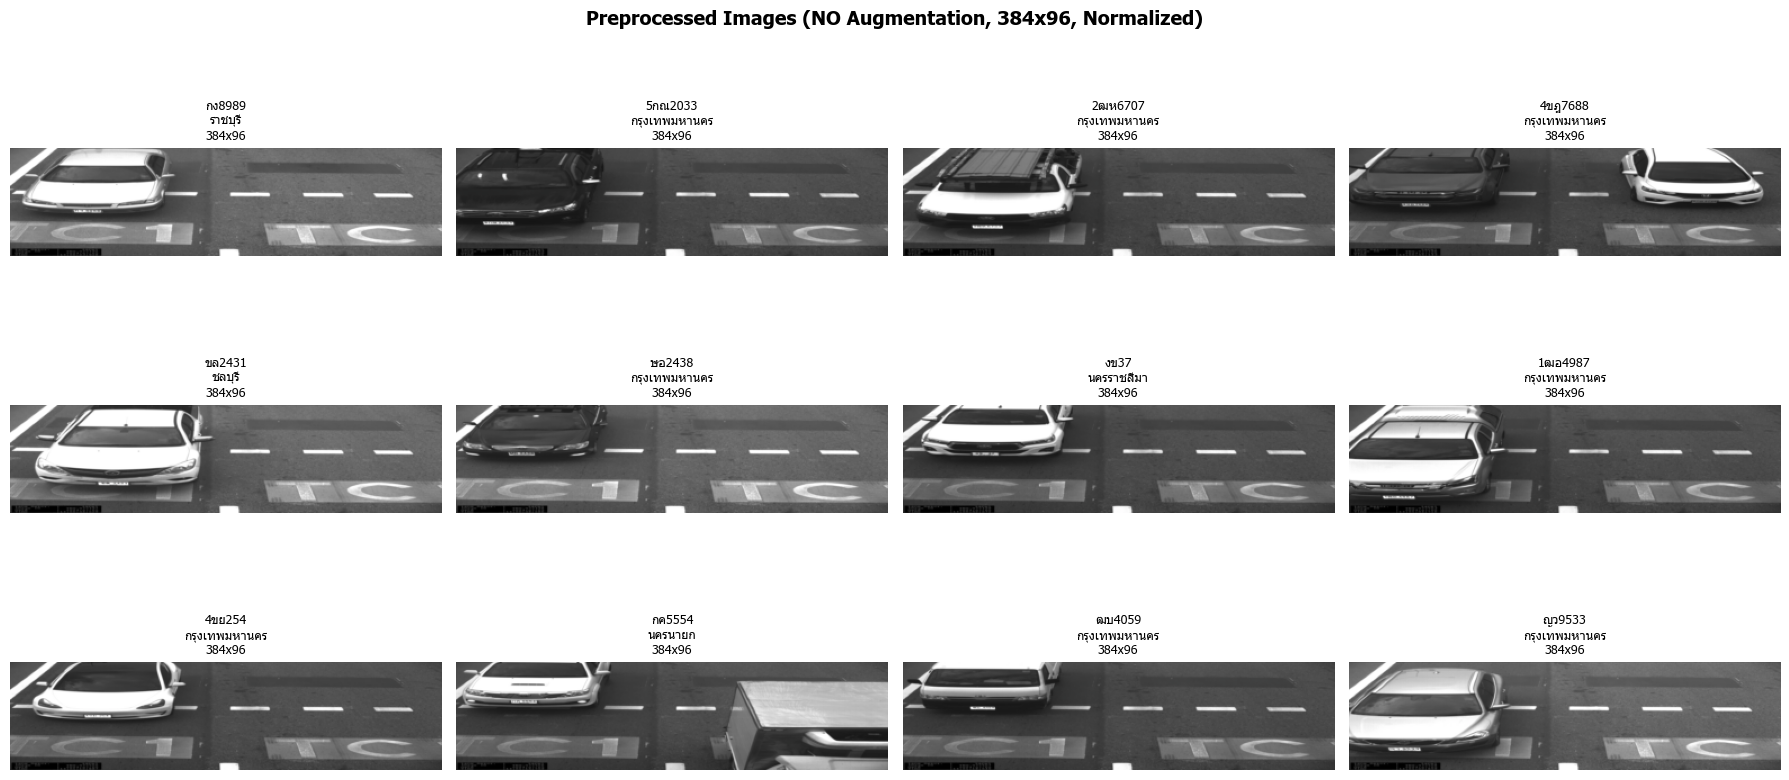

In [11]:
# แสดงภาพแบบไม่มี augmentation (validation/test set)
print("🔍 Images WITHOUT augmentation (ที่จะเข้า validation/test):")
visualize_preprocessed_images(records, augment_fn=None, 
                              target_height=96, target_width=384,
                              num_samples=12, cols=4)

## สรุปการดึงภาพของ train_ctc.py

**วิธีการดึงภาพ:**

1. ใช้ `load_records()` โหลดข้อมูลจาก CSV → ได้ `LicensePlateRecord` objects
2. ใช้ `load_plate_crop(record)` ดึงภาพทะเบียนที่ crop แล้ว (PIL Image RGB)
3. **ไม่ได้ crop เอง** จากภาพรถ → แตกต่างจาก yolo_splitter.ipynb
4. Apply augmentation (ถ้าเป็น training set)
5. Resize เป็น target size (default 384x96)
6. Convert to tensor และ normalize ด้วย ImageNet stats

**ความแตกต่างจาก yolo_splitter.ipynb:**

- **train_ctc.py**: ใช้ภาพที่ crop ไว้แล้ว (plate_image_path) → ง่าย สะดวก
- **yolo_splitter.ipynb**: ดึงภาพรถเต็ม → crop ด้วย car_bbox + plate_bbox → ยืดหยุ่นกว่า
